In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Column names from the readme
col_names = ['engine_id', 'cycle', 
             'setting1', 'setting2', 'setting3',
             's1','s2','s3','s4','s5','s6','s7',
             's8','s9','s10','s11','s12','s13',
             's14','s15','s16','s17','s18','s19',
             's20','s21']

# Load — the file has trailing spaces so we get phantom columns, drop them
df = pd.read_csv('../data/raw/train_FD001.txt', 
                  sep='\s+', 
                  header=None,
                  names=col_names)

print(df.shape)
print(df.head())

(20631, 26)
   engine_id  cycle  setting1  setting2  setting3      s1      s2       s3  \
0          1      1   -0.0007   -0.0004     100.0  518.67  641.82  1589.70   
1          1      2    0.0019   -0.0003     100.0  518.67  642.15  1591.82   
2          1      3   -0.0043    0.0003     100.0  518.67  642.35  1587.99   
3          1      4    0.0007    0.0000     100.0  518.67  642.35  1582.79   
4          1      5   -0.0019   -0.0002     100.0  518.67  642.37  1582.85   

        s4     s5  ...     s12      s13      s14     s15   s16  s17   s18  \
0  1400.60  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388   
1  1403.14  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388   
2  1404.20  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388   
3  1401.87  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388   
4  1406.22  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388   

     s19    s20      s21  
0  100.0  39.06  23.4190  
1 

In [4]:
# For each engine, find its last cycle (the failure point)
max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

# Merge back and compute RUL
df = df.merge(max_cycles, on='engine_id')
df['RUL'] = df['max_cycle'] - df['cycle']
df.drop(columns=['max_cycle'], inplace=True)

print(df[['engine_id', 'cycle', 'RUL']].head(20))

    engine_id  cycle  RUL
0           1      1  191
1           1      2  190
2           1      3  189
3           1      4  188
4           1      5  187
5           1      6  186
6           1      7  185
7           1      8  184
8           1      9  183
9           1     10  182
10          1     11  181
11          1     12  180
12          1     13  179
13          1     14  178
14          1     15  177
15          1     16  176
16          1     17  175
17          1     18  174
18          1     19  173
19          1     20  172


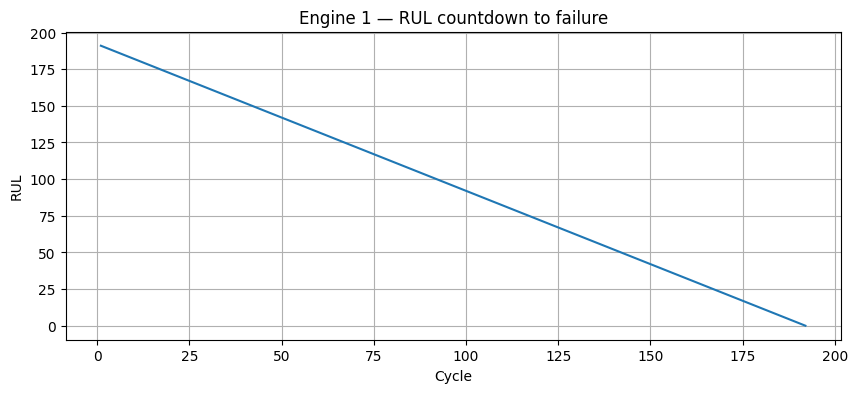

In [5]:
engine_1 = df[df['engine_id'] == 1][['cycle', 'RUL']]

plt.figure(figsize=(10, 4))
plt.plot(engine_1['cycle'], engine_1['RUL'])
plt.xlabel('Cycle')
plt.ylabel('RUL')
plt.title('Engine 1 — RUL countdown to failure')
plt.grid(True)
plt.show()